# PipelineE K=3 state physiology notebook (Schaefer-adapted)

This notebook turns the saved **fusion HMM outputs** into **parcel-level** and **network-level** state maps, using the same atlas family you used earlier in preprocessing and Brainstorm:

- **Schaefer2018**
- **200 parcels**
- **7 canonical networks**
- **MNI152NLin2009cAsym** volumetric atlas from TemplateFlow

Main goals:
1. Reconstruct each state's **parcel × parcel BOLD correlation matrix** from the saved `state_signature_ut_boldcorr.npy`.
2. Attach **Schaefer parcel labels** and **7-network labels** from the TemplateFlow TSV (or the Brainstorm `.txt` if needed).
3. Produce manuscript-grade figures for:
   - state-wise parcel-level correlation maps
   - state differences versus the dominant/reference state
   - network block summaries
   - top network and parcel contrasts
4. Optionally reconstruct **state-wise BOLD covariance matrices** from `covs_pca.npy` if `preproc_params.npz` is available.

This notebook is designed to work directly with the **saved PipelineE outputs** and to fail clearly when an optional dependency is missing.


In [1]:
from pathlib import Path
import json, math, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
# =========================
# User config
# =========================

# Point this to the PipelineE OUT_ROOT folder (not the /final folder)
RESULT_ROOT = Path(
    "/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/"
    "PipelineE_final_K03_intermediate_nolags_minlen15"
)
FINAL_DIR = RESULT_ROOT / "final"

# Atlas paths based on the actual preprocessing/Brainstorm setup you documented.
# TemplateFlow cache was placed in a Windows-visible path so Brainstorm could read it.
TEMPLATEFLOW_HOME = Path("/mnt/c/EEGFMRI_PIPELINE/templateflow")
TF_TPL_DIR = TEMPLATEFLOW_HOME / "tpl-MNI152NLin2009cAsym"
DEFAULT_SCHAEFER_TSV = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv"
DEFAULT_SCHAEFER_NII = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.nii.gz"
DEFAULT_BRAINSTORM_TXT = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.txt"

# If None, the notebook first tries the Schaefer TemplateFlow TSV above,
# then the Brainstorm .txt with the same atlas basename, then generic auto-search.
PARCEL_LABELS_FILE = None

# Optional: if None, the notebook will use RESULT_ROOT / "preproc_params.npz" if present.
# Needed only for optional covariance backprojection from covs_pca.npy.
PREPROC_PARAMS_FILE = None

# Which state should be treated as the reference / baseline for difference plots?
# If None, choose the dominant state from the final FO vector.
REFERENCE_STATE = None  # e.g., 2 for S2

# Use signed block means by default. Set True only if you want |r| summaries.
USE_ABS_FOR_BLOCK_MEANS = False

# Canonical Schaefer-7 network order for figures/tables.
NETWORK_ORDER = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]

# Output folder for figures and tables made by this notebook.
FIG_DIR = RESULT_ROOT / "physiology_review_schaefer"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("RESULT_ROOT       :", RESULT_ROOT)
print("FINAL_DIR         :", FINAL_DIR)
print("DEFAULT_SCHAEFER_TSV :", DEFAULT_SCHAEFER_TSV)
print("DEFAULT_BRAINSTORM_TXT:", DEFAULT_BRAINSTORM_TXT)
print("FIG_DIR           :", FIG_DIR)


RESULT_ROOT       : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15
FINAL_DIR         : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final
DEFAULT_SCHAEFER_TSV : /mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv
DEFAULT_BRAINSTORM_TXT: /mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.txt
FIG_DIR           : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/physiology_review_schaefer


In [3]:
# =========================
# Path helpers
# =========================

def resolve_existing(*candidates):
    for c in candidates:
        if c is None:
            continue
        p = Path(c)
        if p.exists():
            return p
    return None

def load_json(path):
    return json.loads(Path(path).read_text())

def infer_result_file(name):
    p = resolve_existing(RESULT_ROOT / name, FINAL_DIR / name, Path(name))
    if p is None:
        raise FileNotFoundError(f"Could not find required file: {name}")
    return p

required = {
    "qc_summary": infer_result_file("qc_summary.json"),
    "subject_metrics": infer_result_file("subject_metrics.tsv"),
    "run_metrics": infer_result_file("run_metrics.tsv"),
    "trans_prob": infer_result_file("trans_prob.npy"),
    "state_signature": infer_result_file("state_signature_ut_boldcorr.npy"),
    "covs_pca": infer_result_file("covs_pca.npy"),
}
optional = {
    "refit_results": resolve_existing(FINAL_DIR / "refit_results.json", RESULT_ROOT / "refit_results.json"),
    "topM_seeds": resolve_existing(RESULT_ROOT / "topM_seeds.json"),
    "dwell_from_A": resolve_existing(RESULT_ROOT / "dwell_from_A.tsv"),
    "preproc_params": resolve_existing(PREPROC_PARAMS_FILE, RESULT_ROOT / "preproc_params.npz"),
    "atlas_tsv": resolve_existing(PARCEL_LABELS_FILE, DEFAULT_SCHAEFER_TSV),
    "atlas_txt": resolve_existing(PARCEL_LABELS_FILE, DEFAULT_BRAINSTORM_TXT),
}

print("Resolved files:")
for k, v in required.items():
    print(f"  {k:16s} -> {v}")
for k, v in optional.items():
    print(f"  {k:16s} -> {v}")


Resolved files:
  qc_summary       -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/qc_summary.json
  subject_metrics  -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/subject_metrics.tsv
  run_metrics      -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/run_metrics.tsv
  trans_prob       -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/trans_prob.npy
  state_signature  -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/state_signature_ut_boldcorr.npy
  covs_pca         -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/cov

In [4]:
# =========================
# Load saved PipelineE outputs
# =========================

qc = load_json(required["qc_summary"])
subj = pd.read_csv(required["subject_metrics"], sep="\t")
runs = pd.read_csv(required["run_metrics"], sep="\t")
A = np.load(required["trans_prob"])
sig_ut = np.load(required["state_signature"])
covs_pca = np.load(required["covs_pca"])

refit_results = load_json(optional["refit_results"]) if optional["refit_results"] else None
topM = load_json(optional["topM_seeds"]) if optional["topM_seeds"] else None
dwell_tbl = pd.read_csv(optional["dwell_from_A"], sep="\t") if optional["dwell_from_A"] else None

print(pd.DataFrame({
    "n_runs": [qc.get("n_runs")],
    "collapsed_run_count": [qc.get("collapsed_run_count")],
    "collapsed_run_rate": [qc.get("collapsed_run_rate")],
    "seed_identifiability_median_mean_state_corr": [qc.get("seed_identifiability_median_mean_state_corr")],
    "seed_identifiability_min_mean_state_corr": [qc.get("seed_identifiability_min_mean_state_corr")],
    "final_seed": [qc.get("final_seed")],
    "final_seed_fe": [qc.get("final_seed_fe")],
    "final_seed_fo_max": [qc.get("final_seed_fo_max")],
    "final_seed_n_active": [qc.get("final_seed_n_active")],
    "final_seed_neff": [qc.get("final_seed_neff")],
}))
print("A shape                :", A.shape)
print("state_signature shape  :", sig_ut.shape)
print("covs_pca shape         :", covs_pca.shape)


   n_runs  collapsed_run_count  collapsed_run_rate  \
0      15                    0                 0.0   

   seed_identifiability_median_mean_state_corr  \
0                                     0.833809   

   seed_identifiability_min_mean_state_corr  final_seed  final_seed_fe  \
0                                  0.738055          23     133.245187   

   final_seed_fo_max  final_seed_n_active  final_seed_neff  
0           0.807597                    3          1.86382  
A shape                : (3, 3)
state_signature shape  : (3, 19900)
covs_pca shape         : (3, 80, 80)


In [5]:
# =========================
# Helpers: reconstruct parcel x parcel matrices from upper triangle vectors
# =========================

def infer_n_from_ut_length(m):
    # m = n*(n-1)/2
    n = int((1 + math.sqrt(1 + 8*m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Upper-triangle length {m} does not correspond to any n x n matrix.")
    return n

def ut_to_square(vec, fill_diag=1.0):
    vec = np.asarray(vec)
    n = infer_n_from_ut_length(vec.size)
    M = np.zeros((n, n), dtype=np.float32)
    iu = np.triu_indices(n, 1)
    M[iu] = vec
    M[(iu[1], iu[0])] = vec
    np.fill_diagonal(M, fill_diag)
    return M

def square_to_ut(M):
    iu = np.triu_indices(M.shape[0], 1)
    return M[iu]

def corr_from_cov(C):
    d = np.sqrt(np.clip(np.diag(C), 1e-12, None))
    return (C / d[:, None]) / d[None, :]

corr_mats = np.stack([ut_to_square(sig_ut[k], fill_diag=1.0) for k in range(sig_ut.shape[0])], axis=0)
K, P, _ = corr_mats.shape
print(f"Recovered {K} state correlation matrices of size {P} x {P}")
assert P == 200, f"Expected 200 parcels for Schaefer-200, but got {P}."


Recovered 3 state correlation matrices of size 200 x 200


In [6]:
# =========================
# Determine final FO vector and dominant/reference state
# =========================

final_fo = None
if refit_results:
    best_seed = qc.get("final_seed")
    hits = [r for r in refit_results if int(r.get("seed")) == int(best_seed)]
    if hits:
        final_fo = np.asarray(hits[0]["fo"], dtype=float)

if final_fo is None:
    fo_cols = [c for c in subj.columns if c.lower().startswith("fo_s")]
    if fo_cols:
        final_fo = subj[fo_cols].mean(axis=0).to_numpy(dtype=float)
    else:
        raise RuntimeError("Could not recover final FO vector from refit_results.json or subject_metrics.tsv")

dominant_state_idx = int(np.argmax(final_fo))
reference_state_idx = (REFERENCE_STATE - 1) if REFERENCE_STATE is not None else dominant_state_idx

print("Final FO vector:", np.round(final_fo, 6))
print("Dominant state :", f"S{dominant_state_idx+1}")
print("Reference state:", f"S{reference_state_idx+1}")


Final FO vector: [0.089823 0.807597 0.10258 ]
Dominant state : S2
Reference state: S2


In [7]:
# =========================
# Atlas / parcel label handling for Schaefer2018 200/7
# =========================

SCHAEFER_NETWORK_MAP = {
    "Vis": "Vis",
    "SomMot": "SomMot",
    "DorsAttn": "DorsAttn",
    "SalVentAttn": "SalVentAttn",
    "Limbic": "Limbic",
    "Cont": "Cont",
    "Default": "Default",
}

# Some Schaefer distributions use abbreviations like SalVentAttn, others may appear as SalVent or VentAttn.
NETWORK_ALIASES = {
    "Vis": "Vis",
    "Visual": "Vis",
    "SomMot": "SomMot",
    "Somatomotor": "SomMot",
    "DorsAttn": "DorsAttn",
    "DorsalAttn": "DorsAttn",
    "SalVentAttn": "SalVentAttn",
    "SalVent": "SalVentAttn",
    "VentAttn": "SalVentAttn",
    "Limbic": "Limbic",
    "Cont": "Cont",
    "Control": "Cont",
    "Default": "Default",
    "DMN": "Default",
}

def auto_find_label_file(result_root):
    candidates = []
    for base in [result_root, result_root.parent, result_root.parent.parent]:
        if base and Path(base).exists():
            for pat in [
                "*label*.tsv", "*labels*.tsv", "*parcel*.tsv", "*lut*.tsv",
                "*label*.csv", "*labels*.csv", "*parcel*.csv", "*lut*.csv",
                "*label*.txt", "*labels*.txt", "*parcel*.txt", "*lut*.txt",
            ]:
                candidates.extend(Path(base).glob(pat))
            for pat in [
                "**/*label*.tsv", "**/*labels*.tsv", "**/*parcel*.tsv", "**/*lut*.tsv",
                "**/*label*.csv", "**/*labels*.csv", "**/*parcel*.csv", "**/*lut*.csv",
            ]:
                hits = list(Path(base).glob(pat))
                candidates.extend(hits[:20])
    seen, uniq = set(), []
    for c in candidates:
        s = str(c)
        if s not in seen:
            seen.add(s)
            uniq.append(c)
    return uniq

def read_brainstorm_label_txt(path):
    rows = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        m = re.match(r"^(\d+)\s+(.+)$", line)
        if not m:
            continue
        rows.append({"index": int(m.group(1)), "label": m.group(2).strip()})
    if not rows:
        raise ValueError(f"Could not parse Brainstorm label txt: {path}")
    return pd.DataFrame(rows)

def standardize_label_table(df, n_expected):
    out = df.copy()
    out.columns = [str(c).strip().lower() for c in out.columns]
    rename_map = {}
    for c in out.columns:
        if c in {"label", "labels", "parcel", "parcel_name", "name", "region"}:
            rename_map[c] = "label"
        elif c in {"network", "net", "rsn"}:
            rename_map[c] = "network"
        elif c in {"hemi", "hemisphere"}:
            rename_map[c] = "hemi"
        elif c in {"index", "idx", "node", "parcel_id", "label_id", "id"}:
            rename_map[c] = "index"
    out = out.rename(columns=rename_map)

    if "label" not in out.columns:
        if out.shape[1] == 1:
            out = out.rename(columns={out.columns[0]: "label"})
        else:
            raise ValueError("Could not find a label column in the label file.")

    if "index" in out.columns:
        out = out.sort_values("index").reset_index(drop=True)
    else:
        out["index"] = np.arange(1, len(out) + 1)

    # Some TSVs may include a background row 0; keep positive labels and then trim.
    out = out[out["index"] > 0].copy().reset_index(drop=True)
    if len(out) < n_expected:
        raise ValueError(f"Label file has only {len(out)} rows after filtering; expected at least {n_expected}.")
    out = out.iloc[:n_expected].copy().reset_index(drop=True)
    return out

def infer_network_from_schaefer_label(label):
    s = str(label).strip()
    tokens = [t for t in re.split(r"[_\-\s]+", s) if t]
    for tok in tokens:
        if tok in NETWORK_ALIASES:
            return NETWORK_ALIASES[tok]
    joined = "_".join(tokens)
    for k, v in NETWORK_ALIASES.items():
        if k in joined:
            return v
    return "Unknown"

def infer_hemi_from_schaefer_label(label):
    s = str(label).strip()
    tokens = [t for t in re.split(r"[_\-\s]+", s) if t]
    if "LH" in tokens or "Left" in tokens:
        return "L"
    if "RH" in tokens or "Right" in tokens:
        return "R"
    sl = s.lower()
    if "_lh_" in sl or sl.startswith("lh_"):
        return "L"
    if "_rh_" in sl or sl.startswith("rh_"):
        return "R"
    return "?"

def compact_schaefer_label(label):
    s = str(label).strip()
    s = re.sub(r"^7Networks_", "", s)
    s = re.sub(r"^17Networks_", "", s)
    return s

def make_fallback_labels(n):
    labels = [f"parcel_{i+1:03d}" for i in range(n)]
    return pd.DataFrame({
        "index": np.arange(1, n + 1),
        "label": labels,
        "label_short": labels,
        "network": ["Unknown"] * n,
        "hemi": ["?"] * n,
    })

def resolve_label_file():
    explicit = resolve_existing(PARCEL_LABELS_FILE)
    if explicit is not None:
        return explicit
    preferred = resolve_existing(DEFAULT_SCHAEFER_TSV, DEFAULT_BRAINSTORM_TXT)
    if preferred is not None:
        return preferred
    hits = auto_find_label_file(RESULT_ROOT)
    return hits[0] if hits else None

def load_parcel_labels(n_expected):
    label_path = resolve_label_file()
    if label_path is None:
        print("No Schaefer label file found automatically. Using fallback parcel labels.")
        return make_fallback_labels(n_expected), None

    label_path = Path(label_path)
    print("Using parcel label file:", label_path)
    if label_path.suffix.lower() == ".txt":
        df = read_brainstorm_label_txt(label_path)
    elif label_path.suffix.lower() == ".csv":
        df = pd.read_csv(label_path)
    else:
        df = pd.read_csv(label_path, sep=None, engine="python")

    out = standardize_label_table(df, n_expected)
    if "network" not in out.columns:
        out["network"] = out["label"].map(infer_network_from_schaefer_label)
    if "hemi" not in out.columns:
        out["hemi"] = out["label"].map(infer_hemi_from_schaefer_label)
    out["label_short"] = out["label"].map(compact_schaefer_label)
    return out[["index", "label", "label_short", "network", "hemi"]].reset_index(drop=True), label_path

def network_sort_list(values):
    values = list(pd.unique(pd.Series(values).astype(str)))
    ordered = [n for n in NETWORK_ORDER if n in values]
    extras = sorted([n for n in values if n not in ordered])
    return ordered + extras

parcel_info, label_path_used = load_parcel_labels(P)
print(parcel_info.head(12))
print(parcel_info["network"].value_counts(dropna=False))

network_boundaries = []
network_tick_pos = []
network_tick_lab = []
current = None
start = 0
for i, net in enumerate(parcel_info["network"].tolist()):
    if current is None:
        current = net
        start = i
    elif net != current:
        network_boundaries.append(i - 0.5)
        network_tick_pos.append((start + i - 1) / 2)
        network_tick_lab.append(current)
        current = net
        start = i
network_tick_pos.append((start + len(parcel_info) - 1) / 2)
network_tick_lab.append(current)

print("Network order in parcel table:", network_tick_lab)


Using parcel label file: /mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv
    index                label label_short network hemi
0       1   7Networks_LH_Vis_1    LH_Vis_1     Vis    L
1       2   7Networks_LH_Vis_2    LH_Vis_2     Vis    L
2       3   7Networks_LH_Vis_3    LH_Vis_3     Vis    L
3       4   7Networks_LH_Vis_4    LH_Vis_4     Vis    L
4       5   7Networks_LH_Vis_5    LH_Vis_5     Vis    L
5       6   7Networks_LH_Vis_6    LH_Vis_6     Vis    L
6       7   7Networks_LH_Vis_7    LH_Vis_7     Vis    L
7       8   7Networks_LH_Vis_8    LH_Vis_8     Vis    L
8       9   7Networks_LH_Vis_9    LH_Vis_9     Vis    L
9      10  7Networks_LH_Vis_10   LH_Vis_10     Vis    L
10     11  7Networks_LH_Vis_11   LH_Vis_11     Vis    L
11     12  7Networks_LH_Vis_12   LH_Vis_12     Vis    L
network
Default        46
SomMot         35
Cont           30
Vis            29
DorsAttn       26
SalVentAttn

In [8]:
# =========================
# Sanity check: saved signature <-> reconstructed matrices
# =========================

max_abs_err = np.max(np.abs(np.stack([square_to_ut(corr_mats[k]) for k in range(K)]) - sig_ut))
print("Max abs reconstruction error from UT vector -> matrix -> UT:", float(max_abs_err))
assert max_abs_err < 1e-6 + 1e-7, "Unexpected reconstruction error."


Max abs reconstruction error from UT vector -> matrix -> UT: 0.0


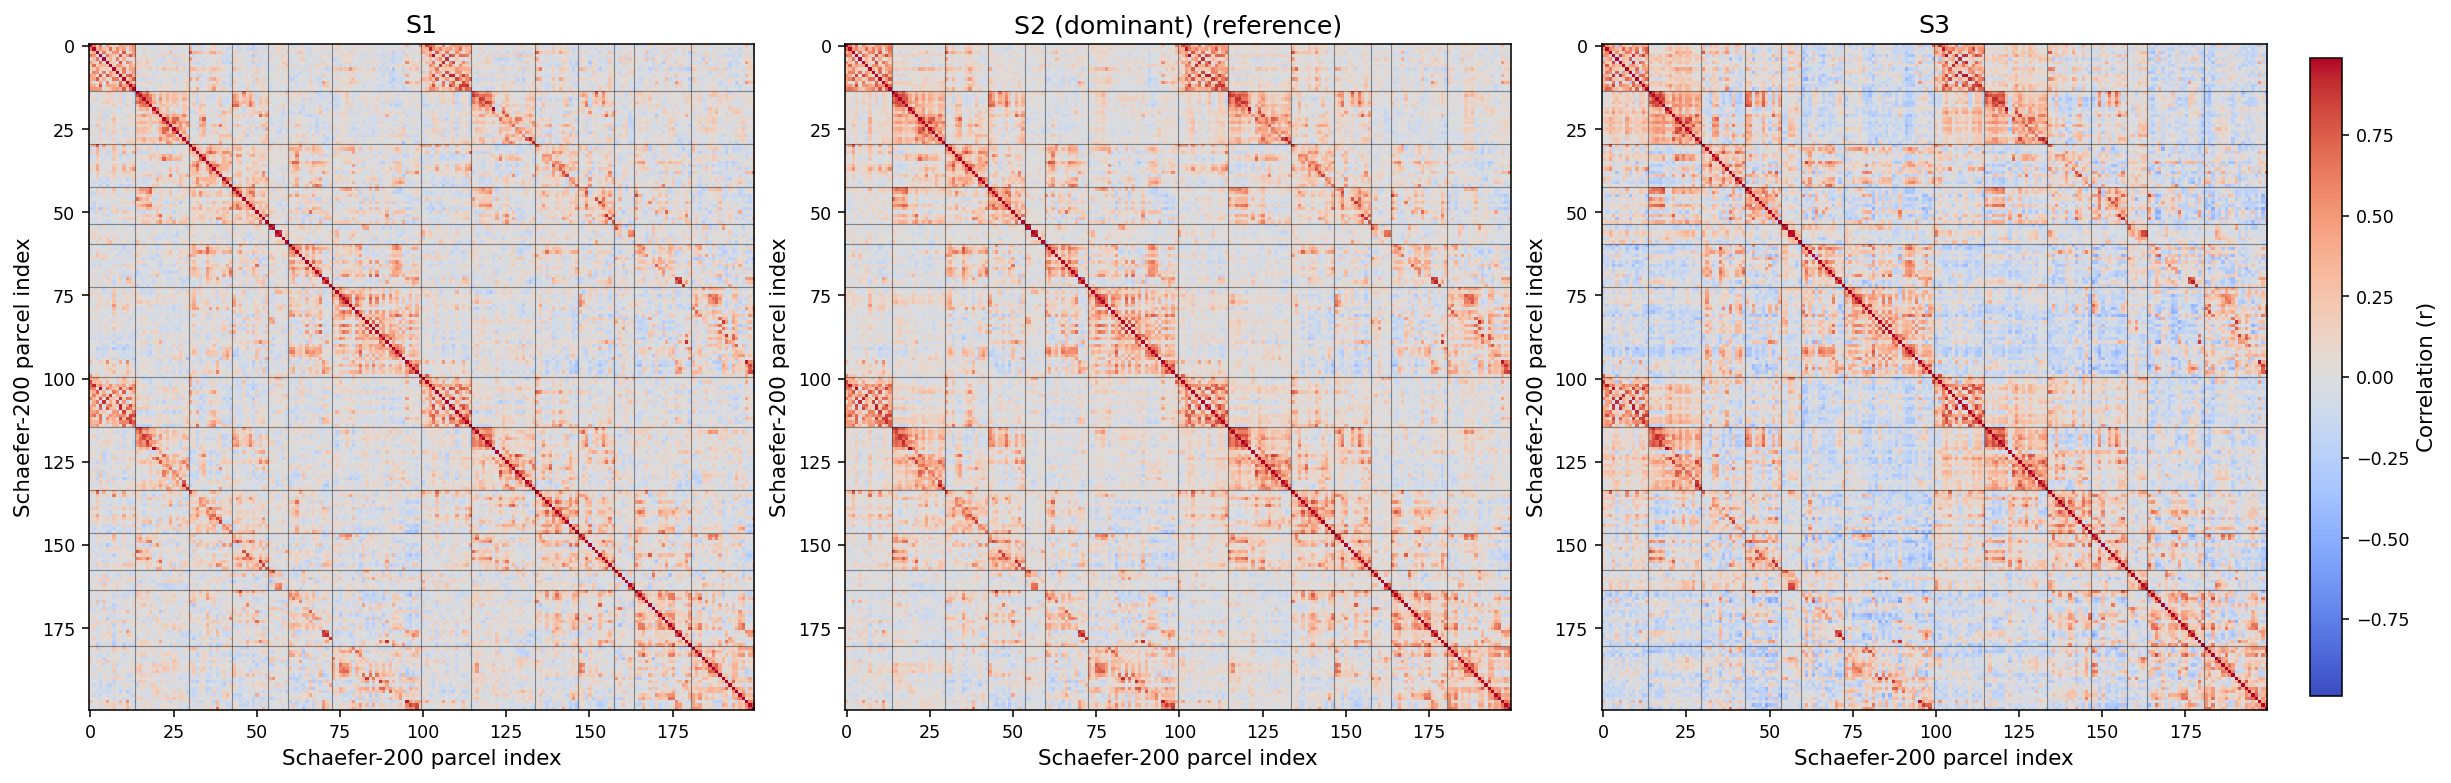

In [9]:
# =========================
# State-wise parcel correlation heatmaps (with Schaefer network boundaries)
# =========================

def savefig(fig, name):
    # Avoid mixing tight_layout() with figures created using constrained_layout=True,
    # especially after colorbars have been added.
    try:
        use_constrained = bool(fig.get_constrained_layout())
    except Exception:
        use_constrained = False

    if not use_constrained:
        try:
            fig.tight_layout()
        except Exception as e:
            print(f"[savefig] tight_layout skipped: {e}")

    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()

mask = ~np.eye(P, dtype=bool)
absmax = float(np.nanmax(np.abs(corr_mats[:, mask])))
norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)

fig, axes = plt.subplots(1, K, figsize=(5.8*K, 5.6), constrained_layout=True)
if K == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    im = ax.imshow(corr_mats[k], cmap="coolwarm", norm=norm, interpolation="nearest")
    title = f"S{k+1}"
    if k == dominant_state_idx:
        title += " (dominant)"
    if k == reference_state_idx:
        title += " (reference)"
    ax.set_title(title)
    ax.set_xlabel("Schaefer-200 parcel index")
    ax.set_ylabel("Schaefer-200 parcel index")
    for b in network_boundaries:
        ax.axhline(b, color="k", lw=0.6, alpha=0.4)
        ax.axvline(b, color="k", lw=0.6, alpha=0.4)
    if len(network_tick_pos) <= 10:
        ax.set_xticks(network_tick_pos)
        ax.set_xticklabels(network_tick_lab, rotation=45, ha="right")
        ax.set_yticks(network_tick_pos)
        ax.set_yticklabels(network_tick_lab)
cbar = fig.colorbar(im, ax=axes, shrink=0.85, fraction=0.03, pad=0.02)
cbar.set_label("Correlation (r)")
savefig(fig, "state_parcel_corr_heatmaps_schaefer.png")


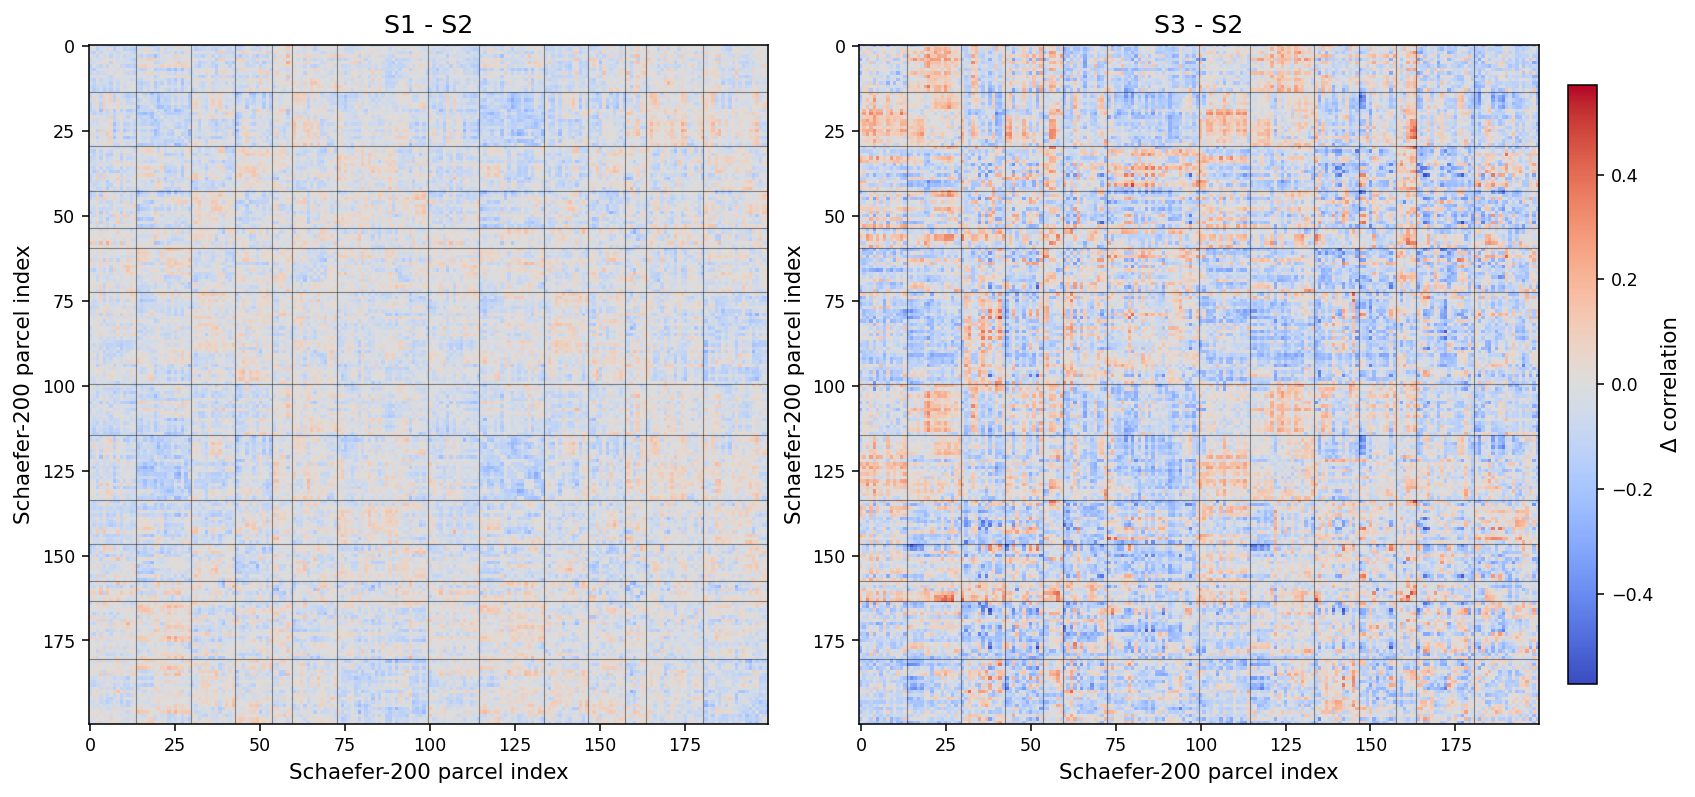

In [10]:
# =========================
# Parcel-level difference maps versus the reference state
# =========================

other_states = [k for k in range(K) if k != reference_state_idx]
if other_states:
    diffs = [corr_mats[k] - corr_mats[reference_state_idx] for k in other_states]
    absmax = float(np.nanmax(np.abs(np.stack(diffs))))
    norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)

    fig, axes = plt.subplots(1, len(other_states), figsize=(6.0*len(other_states), 5.6), constrained_layout=True)
    if len(other_states) == 1:
        axes = [axes]
    for ax, k in zip(axes, other_states):
        im = ax.imshow(corr_mats[k] - corr_mats[reference_state_idx], cmap="coolwarm", norm=norm, interpolation="nearest")
        ax.set_title(f"S{k+1} - S{reference_state_idx+1}")
        ax.set_xlabel("Schaefer-200 parcel index")
        ax.set_ylabel("Schaefer-200 parcel index")
        for b in network_boundaries:
            ax.axhline(b, color="k", lw=0.6, alpha=0.4)
            ax.axvline(b, color="k", lw=0.6, alpha=0.4)
        if len(network_tick_pos) <= 10:
            ax.set_xticks(network_tick_pos)
            ax.set_xticklabels(network_tick_lab, rotation=45, ha="right")
            ax.set_yticks(network_tick_pos)
            ax.set_yticklabels(network_tick_lab)
    cbar = fig.colorbar(im, ax=axes, shrink=0.85, fraction=0.03, pad=0.02)
    cbar.set_label("Δ correlation")
    savefig(fig, "state_parcel_corr_differences_vs_reference_schaefer.png")


In [11]:
# =========================
# Network-level block summaries (Schaefer-7 ordering)
# =========================

def block_mean(M, labels_df, use_abs=False, network_order=None):
    vals = np.abs(M) if use_abs else M
    nets_raw = labels_df["network"].astype(str).tolist()
    uniq = network_sort_list(nets_raw) if network_order is None else [n for n in network_order if n in set(nets_raw)] + [n for n in sorted(set(nets_raw)) if n not in (network_order or [])]
    B = np.full((len(uniq), len(uniq)), np.nan, dtype=float)

    for i, ni in enumerate(uniq):
        ii = np.where(labels_df["network"].values == ni)[0]
        for j, nj in enumerate(uniq):
            jj = np.where(labels_df["network"].values == nj)[0]
            sub = vals[np.ix_(ii, jj)]
            if i == j:
                mask = ~np.eye(len(ii), dtype=bool)
                use = sub[mask] if len(ii) > 1 else np.array([np.nan])
            else:
                use = sub.reshape(-1)
            B[i, j] = np.nanmean(use)
    return uniq, B

network_blocks = {}
for k in range(K):
    nets, B = block_mean(corr_mats[k], parcel_info, use_abs=USE_ABS_FOR_BLOCK_MEANS, network_order=NETWORK_ORDER)
    network_blocks[f"S{k+1}"] = pd.DataFrame(B, index=nets, columns=nets)

print(network_blocks["S1"])


                  Vis    SomMot  DorsAttn  SalVentAttn    Limbic      Cont  \
Vis          0.348612  0.016861  0.041832     0.001992  0.023366 -0.002295   
SomMot       0.016861  0.246697  0.039631     0.102653 -0.006882  0.005223   
DorsAttn     0.041832  0.039631  0.239659     0.108518  0.020143  0.082863   
SalVentAttn  0.001992  0.102653  0.108518     0.232641  0.007551  0.055388   
Limbic       0.023366 -0.006882  0.020143     0.007551  0.128692  0.020110   
Cont        -0.002295  0.005223  0.082863     0.055388  0.020110  0.176928   
Default      0.006333  0.015400  0.008690     0.010411  0.012970  0.046540   

              Default  
Vis          0.006333  
SomMot       0.015400  
DorsAttn     0.008690  
SalVentAttn  0.010411  
Limbic       0.012970  
Cont         0.046540  
Default      0.177747  


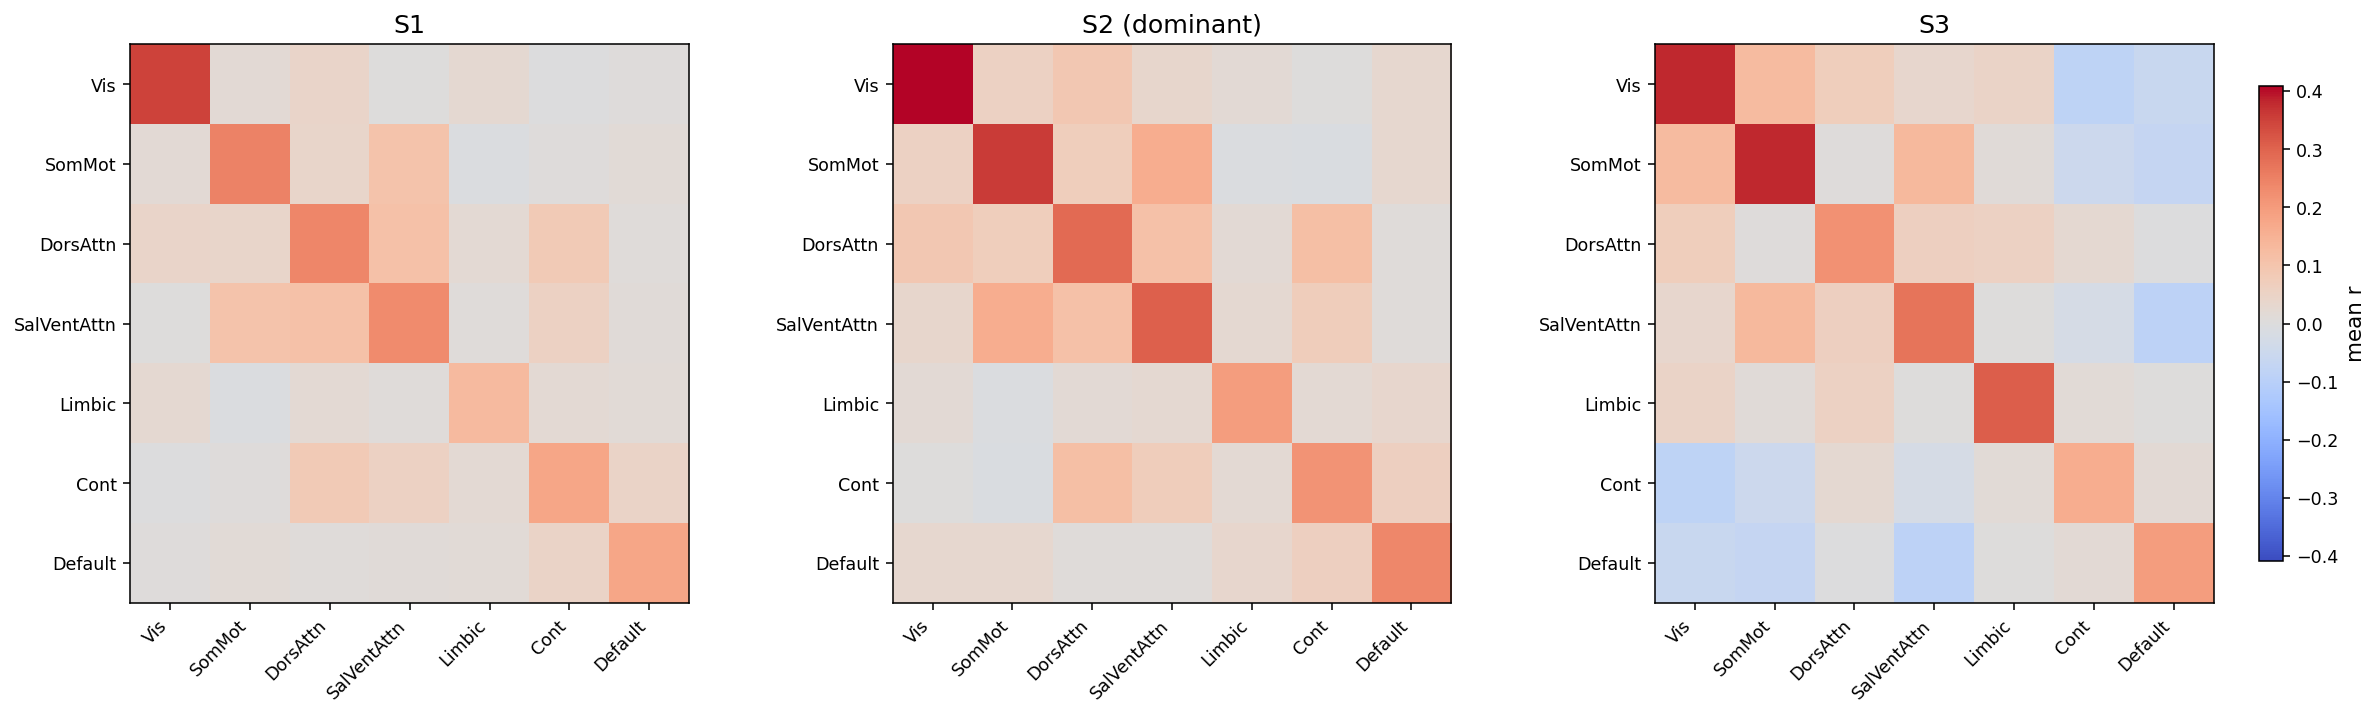

In [12]:
# =========================
# Plot state-wise network block heatmaps
# =========================

blocks = [network_blocks[f"S{k+1}"].to_numpy() for k in range(K)]
absmax = float(np.nanmax(np.abs(np.stack(blocks))))
norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)

fig, axes = plt.subplots(1, K, figsize=(5.8*K, 5.0), constrained_layout=True)
if K == 1:
    axes = [axes]

labels_n = network_blocks["S1"].index.tolist()
for k, ax in enumerate(axes):
    mat = network_blocks[f"S{k+1}"].to_numpy()
    im = ax.imshow(mat, cmap="coolwarm", norm=norm, interpolation="nearest")
    title = f"S{k+1}"
    if k == dominant_state_idx:
        title += " (dominant)"
    ax.set_title(title)
    ax.set_xticks(range(len(labels_n)))
    ax.set_yticks(range(len(labels_n)))
    ax.set_xticklabels(labels_n, rotation=45, ha="right")
    ax.set_yticklabels(labels_n)
cbar = fig.colorbar(im, ax=axes, shrink=0.85, fraction=0.03, pad=0.02)
cbar.set_label("|r|" if USE_ABS_FOR_BLOCK_MEANS else "mean r")
savefig(fig, "state_network_block_heatmaps_schaefer.png")


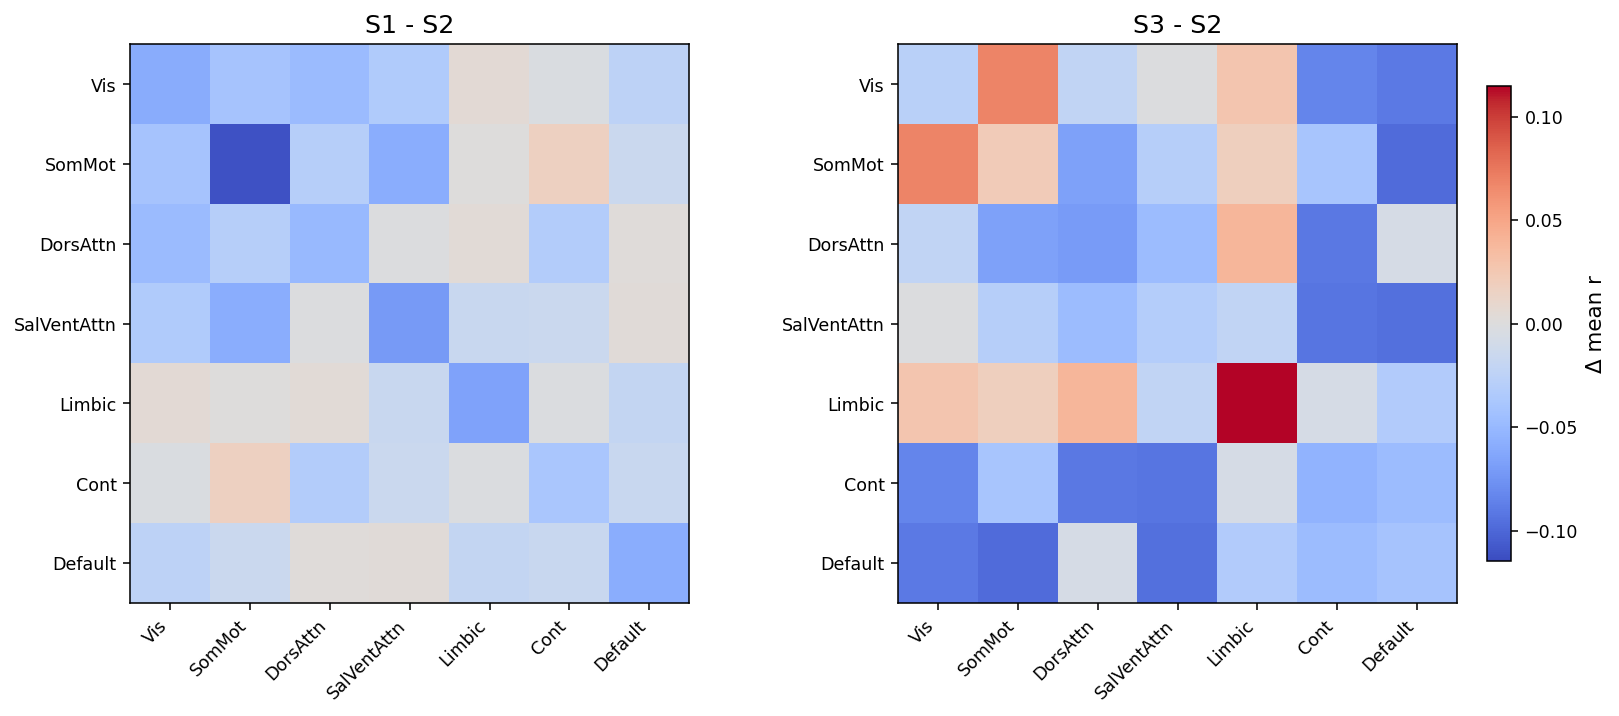

In [13]:
# =========================
# Plot network block differences versus the reference state
# =========================

other_states = [k for k in range(K) if k != reference_state_idx]
if other_states:
    diffs = [network_blocks[f"S{k+1}"].to_numpy() - network_blocks[f"S{reference_state_idx+1}"].to_numpy()
             for k in other_states]
    absmax = float(np.nanmax(np.abs(np.stack(diffs))))
    norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)

    fig, axes = plt.subplots(1, len(other_states), figsize=(6.0*len(other_states), 5.0), constrained_layout=True)
    if len(other_states) == 1:
        axes = [axes]

    for ax, k in zip(axes, other_states):
        diff = network_blocks[f"S{k+1}"].to_numpy() - network_blocks[f"S{reference_state_idx+1}"].to_numpy()
        im = ax.imshow(diff, cmap="coolwarm", norm=norm, interpolation="nearest")
        ax.set_title(f"S{k+1} - S{reference_state_idx+1}")
        ax.set_xticks(range(len(labels_n)))
        ax.set_yticks(range(len(labels_n)))
        ax.set_xticklabels(labels_n, rotation=45, ha="right")
        ax.set_yticklabels(labels_n)
    cbar = fig.colorbar(im, ax=axes, shrink=0.85, fraction=0.03, pad=0.02)
    cbar.set_label("Δ " + ("|r|" if USE_ABS_FOR_BLOCK_MEANS else "mean r"))
    savefig(fig, "state_network_block_differences_vs_reference_schaefer.png")


In [14]:
# =========================
# Rank the biggest network-pair contrasts versus the reference state
# =========================

def network_contrast_table(state_idx, ref_idx):
    A_ = network_blocks[f"S{state_idx+1}"]
    R_ = network_blocks[f"S{ref_idx+1}"]
    D = A_ - R_
    rows = []
    for i in A_.index:
        for j in A_.columns:
            rows.append({
                "state": f"S{state_idx+1}",
                "reference": f"S{ref_idx+1}",
                "pair": f"{i} -- {j}",
                "delta": float(D.loc[i, j]),
                "state_value": float(A_.loc[i, j]),
                "reference_value": float(R_.loc[i, j]),
            })
    out = pd.DataFrame(rows)
    out["abs_delta"] = out["delta"].abs()
    return out.sort_values(["abs_delta", "pair"], ascending=[False, True]).reset_index(drop=True)

network_contrasts = {}
for k in range(K):
    if k == reference_state_idx:
        continue
    tbl = network_contrast_table(k, reference_state_idx)
    network_contrasts[f"S{k+1}_vs_S{reference_state_idx+1}"] = tbl
    print("\nTop network contrasts for", f"S{k+1} vs S{reference_state_idx+1}")
    print(tbl.head(15))

for name, tbl in network_contrasts.items():
    tbl.to_csv(FIG_DIR / f"{name}_top_network_contrasts.tsv", sep="\t", index=False)



Top network contrasts for S1 vs S2
   state reference                        pair     delta  state_value  \
0     S1        S2            SomMot -- SomMot -0.111985     0.246697   
1     S1        S2  SalVentAttn -- SalVentAttn -0.071521     0.232641   
2     S1        S2            Limbic -- Limbic -0.066071     0.128692   
3     S1        S2                  Vis -- Vis -0.059796     0.348612   
4     S1        S2          Default -- Default -0.059066     0.177747   
5     S1        S2       SalVentAttn -- SomMot -0.058401     0.102653   
6     S1        S2       SomMot -- SalVentAttn -0.058401     0.102653   
7     S1        S2        DorsAttn -- DorsAttn -0.049662     0.239659   
8     S1        S2             DorsAttn -- Vis -0.048379     0.041832   
9     S1        S2             Vis -- DorsAttn -0.048379     0.041832   
10    S1        S2               SomMot -- Vis -0.040347     0.016861   
11    S1        S2               Vis -- SomMot -0.040347     0.016861   
12    S1       

In [15]:
# =========================
# Nodal summaries: mean connectivity strength per parcel
# =========================

def offdiag_row_mean(M):
    M = np.asarray(M, float)
    n = M.shape[0]
    out = (M.sum(axis=1) - np.diag(M)) / np.maximum(n - 1, 1)
    return out

nodal = parcel_info.copy()
for k in range(K):
    nodal[f"S{k+1}_mean_r"] = offdiag_row_mean(corr_mats[k])

for k in range(K):
    print("\nTop parcels for", f"S{k+1}")
    print(
        nodal[["index", "label_short", "network", "hemi", f"S{k+1}_mean_r"]]
        .sort_values(f"S{k+1}_mean_r", ascending=False)
        .head(15)
    )

nodal.to_csv(FIG_DIR / "nodal_mean_connectivity_by_state.tsv", sep="\t", index=False)



Top parcels for S1
     index                  label_short      network hemi  S1_mean_r
15      16                  LH_SomMot_2       SomMot    L   0.103268
141    142           RH_DorsAttn_Post_8     DorsAttn    R   0.099337
37      38           LH_DorsAttn_Post_8     DorsAttn    L   0.096182
17      18                  LH_SomMot_4       SomMot    L   0.095315
113    114                    RH_Vis_14          Vis    R   0.092730
104    105                     RH_Vis_5          Vis    R   0.092004
175    176               RH_Cont_PFCl_7         Cont    R   0.091374
154    155      RH_SalVentAttn_FrOper_4  SalVentAttn    R   0.090190
14      15                  LH_SomMot_1       SomMot    L   0.089904
125    126                 RH_SomMot_11       SomMot    R   0.089070
140    141           RH_DorsAttn_Post_7     DorsAttn    R   0.089060
187    188            RH_Default_Temp_4      Default    R   0.088879
149    150  RH_SalVentAttn_TempOccPar_3  SalVentAttn    R   0.088509
116    117    

In [16]:
# =========================
# Parcel-wise contrasts versus the reference state
# =========================

parcel_contrast_tables = {}
for k in range(K):
    if k == reference_state_idx:
        continue
    tbl = parcel_info.copy()
    tbl["delta_mean_r"] = offdiag_row_mean(corr_mats[k] - corr_mats[reference_state_idx])
    tbl["abs_delta_mean_r"] = tbl["delta_mean_r"].abs()
    tbl = tbl.sort_values(["abs_delta_mean_r", "label"], ascending=[False, True]).reset_index(drop=True)
    parcel_contrast_tables[f"S{k+1}_vs_S{reference_state_idx+1}"] = tbl
    print("\nTop parcel contrasts for", f"S{k+1} vs S{reference_state_idx+1}")
    print(tbl[["index", "label_short", "network", "hemi", "delta_mean_r", "abs_delta_mean_r"]].head(20))
    tbl.to_csv(FIG_DIR / f"S{k+1}_vs_S{reference_state_idx+1}_top_parcel_contrasts.tsv", sep="\t", index=False)



Top parcel contrasts for S1 vs S2
    index               label_short      network hemi  delta_mean_r  \
0      44  LH_SalVentAttn_ParOper_1  SalVentAttn    L     -0.047514   
1      16               LH_SomMot_2       SomMot    L     -0.046746   
2      17               LH_SomMot_3       SomMot    L     -0.045957   
3      19               LH_SomMot_5       SomMot    L     -0.045730   
4      24              LH_SomMot_10       SomMot    L     -0.045266   
5     116               RH_SomMot_1       SomMot    R     -0.044473   
6     119               RH_SomMot_4       SomMot    R     -0.044425   
7       8                  LH_Vis_8          Vis    L     -0.044359   
8     117               RH_SomMot_2       SomMot    R     -0.044238   
9     125              RH_SomMot_10       SomMot    R     -0.043704   
10     15               LH_SomMot_1       SomMot    L     -0.043139   
11    127              RH_SomMot_12       SomMot    R     -0.041545   
12    151      RH_SalVentAttn_PrC_1  SalVe

In [17]:
# =========================
# Optional: covariance backprojection from covs_pca.npy using preproc_params.npz
# =========================

def ensure_cov_3d(covs):
    covs = np.asarray(covs)
    if covs.ndim == 2:
        covs = covs[None, ...]
    return covs

def backproject_cov_bold(covs_pca, Vb, nbpc):
    covs_pca = ensure_cov_3d(covs_pca)
    out = []
    for k in range(covs_pca.shape[0]):
        Cbb = covs_pca[k, :nbpc, :nbpc]
        out.append((Vb @ Cbb @ Vb.T).astype(np.float32))
    return np.stack(out, axis=0)

cov_bold = None
if optional["preproc_params"] and Path(optional["preproc_params"]).exists():
    pp = np.load(optional["preproc_params"])
    Vb = pp["Vb"]
    nbpc = Vb.shape[1]
    cov_bold = backproject_cov_bold(covs_pca, Vb, nbpc)
    print("Backprojected BOLD covariance shape:", cov_bold.shape)

    cov_corr = np.stack([corr_from_cov(C) for C in cov_bold], axis=0)
    err = np.max(np.abs(cov_corr - corr_mats))
    print("Max abs error between backprojected corr and saved corr:", float(err))
else:
    print("preproc_params.npz not found. Skipping covariance backprojection.")


Backprojected BOLD covariance shape: (3, 200, 200)
Max abs error between backprojected corr and saved corr: 5.364418029785156e-07


In [18]:
# =========================
# Summary tables for manuscript writing
# =========================

summary_rows = []
for k in range(K):
    state = f"S{k+1}"
    row = {
        "state": state,
        "is_dominant": int(k == dominant_state_idx),
        "is_reference": int(k == reference_state_idx),
        "final_FO": float(final_fo[k]) if k < len(final_fo) else np.nan,
        "self_transition_Akk": float(A[k, k]),
        "expected_dwell_TR": float(1.0 / max(1e-12, 1.0 - A[k, k])),
    }
    nb = network_blocks[state].copy()
    pairs = []
    for i in nb.index:
        for j in nb.columns:
            pairs.append((i, j, float(nb.loc[i, j])))
    pairs = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
    for rank, (i, j, v) in enumerate(pairs[:5], start=1):
        row[f"top_block_{rank}"] = f"{i} -- {j}"
        row[f"top_block_{rank}_value"] = v
    summary_rows.append(row)

state_summary = pd.DataFrame(summary_rows)
print(state_summary)
state_summary.to_csv(FIG_DIR / "state_summary_table.tsv", sep="\t", index=False)


  state  is_dominant  is_reference  final_FO  self_transition_Akk  \
0    S1            0             0  0.089823             0.183623   
1    S2            1             1  0.807597             0.839828   
2    S3            0             0  0.102580             0.233922   

   expected_dwell_TR top_block_1  top_block_1_value       top_block_2  \
0           1.224924  Vis -- Vis           0.348612  SomMot -- SomMot   
1           6.243287  Vis -- Vis           0.408409  SomMot -- SomMot   
2           1.305351  Vis -- Vis           0.381193  SomMot -- SomMot   

   top_block_2_value                 top_block_3  top_block_3_value  \
0           0.246697        DorsAttn -- DorsAttn           0.239659   
1           0.358683  SalVentAttn -- SalVentAttn           0.304162   
2           0.380916            Limbic -- Limbic           0.309490   

                  top_block_4  top_block_4_value           top_block_5  \
0  SalVentAttn -- SalVentAttn           0.232641    Default -- Default 

In [19]:
# =========================
# Plain-language interpretation scaffold
# =========================

def top_pair_text(tbl, n=5):
    bits = []
    for _, r in tbl.head(n).iterrows():
        bits.append(f"{r['pair']} ({r['delta']:+.3f})")
    return "; ".join(bits)

print("Suggested interpretation scaffold:\n")
for k in range(K):
    state = f"S{k+1}"
    if k == reference_state_idx:
        print(f"{state}: reference state. Final FO={final_fo[k]:.3f}, A_kk={A[k,k]:.3f}, expected dwell={1/(1-A[k,k]):.2f} TR.")
    else:
        tbl = network_contrasts[f"S{k+1}_vs_S{reference_state_idx+1}"]
        print(
            f"{state} versus S{reference_state_idx+1}: "
            f"Final FO={final_fo[k]:.3f}; A_kk={A[k,k]:.3f}; "
            f"largest network shifts include {top_pair_text(tbl, n=5)}."
        )


Suggested interpretation scaffold:

S1 versus S2: Final FO=0.090; A_kk=0.184; largest network shifts include SomMot -- SomMot (-0.112); SalVentAttn -- SalVentAttn (-0.072); Limbic -- Limbic (-0.066); Vis -- Vis (-0.060); Default -- Default (-0.059).
S2: reference state. Final FO=0.808, A_kk=0.840, expected dwell=6.24 TR.
S3 versus S2: Final FO=0.103; A_kk=0.234; largest network shifts include Limbic -- Limbic (+0.115); Default -- SomMot (-0.098); SomMot -- Default (-0.098); Default -- SalVentAttn (-0.096); SalVentAttn -- Default (-0.096).


In [20]:
# =========================
# Save a compact session manifest
# =========================

manifest = {
    "RESULT_ROOT": str(RESULT_ROOT),
    "FINAL_DIR": str(FINAL_DIR),
    "FIG_DIR": str(FIG_DIR),
    "TEMPLATEFLOW_HOME": str(TEMPLATEFLOW_HOME),
    "DEFAULT_SCHAEFER_TSV": str(DEFAULT_SCHAEFER_TSV),
    "DEFAULT_BRAINSTORM_TXT": str(DEFAULT_BRAINSTORM_TXT),
    "label_file_used": str(label_path_used) if label_path_used is not None else None,
    "PREPROC_PARAMS_FILE": str(PREPROC_PARAMS_FILE) if PREPROC_PARAMS_FILE is not None else str(optional["preproc_params"]) if optional["preproc_params"] else None,
    "P": int(P),
    "K": int(K),
    "dominant_state": int(dominant_state_idx + 1),
    "reference_state": int(reference_state_idx + 1),
    "network_order": NETWORK_ORDER,
}
(Path(FIG_DIR) / "physiology_notebook_manifest.json").write_text(json.dumps(manifest, indent=2))
print("Saved outputs to:", FIG_DIR)


Saved outputs to: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/physiology_review_schaefer
